In [1]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load and preprocess the MNIST dataset
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()
x_train = (x_train.astype('float32') - 127.5) / 127.5     # Normalize to [-1,1]
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)

In [3]:
# Hypermeters
latent_dim = 100     # Size of noise vector
batch_size = 64
epochs = 5000
sample_interval = 1000

In [4]:
# Generator Model
def build_generator():
    model = tf.keras.Sequential([
        layers.Dense(128, activation = "relu", input_dim = latent_dim), 
        layers.BatchNormalization(), 
        layers.Dense(256, activation = "relu"), 
        layers.BatchNormalization(), 
        layers.Dense(512, activation = "relu"), 
        layers.BatchNormalization(),
        layers.Dense(28*28*1, activation= "tanh"), 
        layers.Reshape((28,28,1))
    ])
    return model


In [5]:
# Discriminator Model
def build_discriminator():
    model = tf.keras.Sequential([
        layers.Flatten(input_shape = (28,28,1)),
        layers.Dense(512,activation = "relu"),
        layers.Dense(256, activation = "relu"),
        layers.Dense(1, activation = "sigmoid")
    ])
    return model

In [6]:
# Build and compile the discriminator
discriminator = build_discriminator()
discriminator.compile(optimizer = tf.keras.optimizers.Adam(0.0002), loss = "binary_crossentropy", metrics = ["accuracy"])

In [7]:
# Build the generator
generator = build_generator()

In [8]:
# Create the GAN by combining generator and discriminator
discriminator.trainable = False         # Freeze discriminator during generator training
gan_input = layers.Input(shape = (latent_dim,))
generated_img = generator(gan_input)
gan_output = discriminator(generated_img)
gan = tf.keras.Model(gan_input, gan_output)
gan.compile(optimizer = tf.keras.optimizers.Adam(0.00002), loss = "binary_crossentropy", metrics = ["accuracy"])

In [9]:
# Training loop
real = np.ones((batch_size, 1))     # labels for real images
fake = np.zeros((batch_size, 1))    # labels for fake images

 0/5000 [D loss : 0.5882351994514465, acc. : 55.46875] [G loss : [0.6123741865158081, 0.75]]


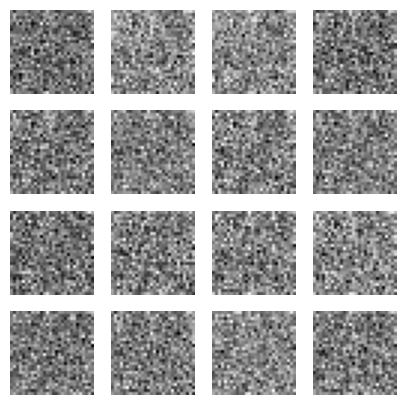

 1000/5000 [D loss : 2.8410228878783528e-05, acc. : 100.0] [G loss : [12.244434356689453, 0.0]]


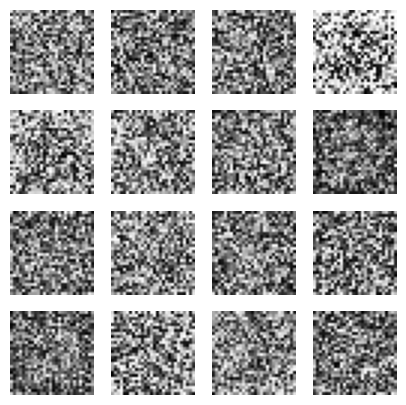

 2000/5000 [D loss : 0.0007050902786431834, acc. : 100.0] [G loss : [16.138477325439453, 0.0]]


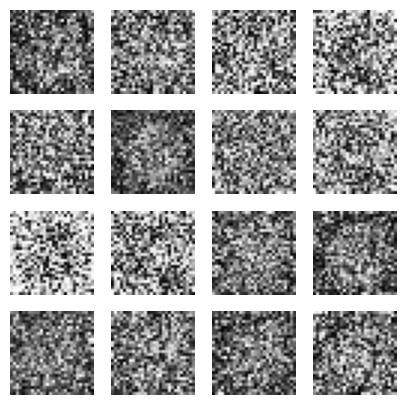

 3000/5000 [D loss : 0.0505858577125764, acc. : 98.4375] [G loss : [11.862998962402344, 0.0]]


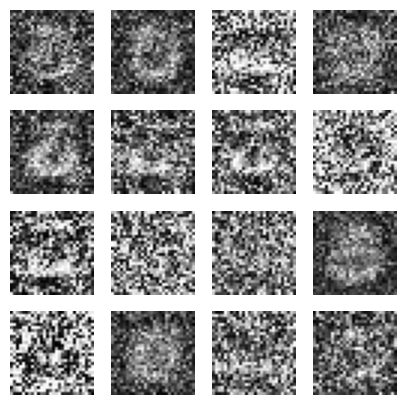

 4000/5000 [D loss : 0.00483653589617461, acc. : 100.0] [G loss : [12.303167343139648, 0.015625]]


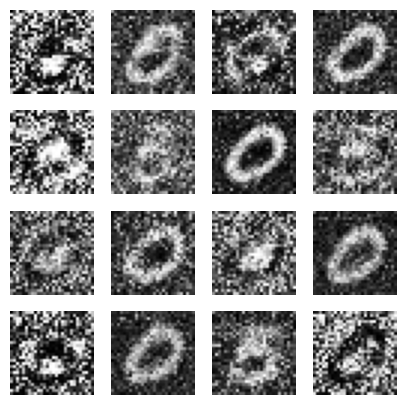

In [10]:
for epoch in range(epochs):
    # Train Discriminator
    idx = np.random.randint(0, x_train.shape[0], batch_size)
    real_imgs = x_train[idx]
    noise = np.random.normal(0,1,(batch_size, latent_dim))
    fake_imgs = generator.predict(noise)
    d_loss_real = discriminator.train_on_batch(real_imgs, real)
    d_loss_fake = discriminator.train_on_batch(fake_imgs, fake)
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    # Train Generator
    noise = np.random.normal(0,1,(batch_size, latent_dim))
    g_loss = gan.train_on_batch(noise, real)

    # print progress
    if epoch % sample_interval == 0:
        print(f" {epoch}/{epochs} [D loss : {d_loss[0]}, acc. : {100 * d_loss[1]}] [G loss : {g_loss}]")

        # Save generated image samples
        noise = np.random.normal(0,1,(16, latent_dim))
        gen_imgs = generator.predict(noise)
        gen_imgs = 0.5 * gen_imgs + 0.5    # Rescale to [0,1]
        fig, axs = plt.subplots(4,4,figsize = (5,5))
        for i in range(4):
            for j in range(4):
                axs[i,j].imshow(gen_imgs[4 * i + j, :, :, 0], cmap = "gray")
                axs[i,j].axis("off")
        plt.show()

In [12]:
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.preprocessing import image
import numpy as np

def preprocess_images(images):
    images_resized = []
    for img in images:
        img_resized = np.array(image.smart_resize(img, (75, 75)))  # Resize to 75x75
        images_resized.append(img_resized)
    return np.array(images_resized)

# Assuming gen_imgs contains generated images
gen_imgs_resized = preprocess_images(gen_imgs)


In [13]:
from tensorflow.keras.applications import InceptionV3
from scipy.stats import entropy

def calculate_inception_score(images, n_split=10):
    model = InceptionV3(include_top=False, pooling='avg', input_shape=(75, 75, 3))
    preds = model.predict(images)
    split_scores = []
    for i in range(n_split):
        part = preds[i * len(preds) // n_split : (i + 1) * len(preds) // n_split]
        py = np.mean(part, axis=0)
        scores = [entropy(pyx, py) for pyx in part]
        split_scores.append(np.exp(np.mean(scores)))
    return np.mean(split_scores), np.std(split_scores)

# Call the function
mean_score, std_score = calculate_inception_score(gen_imgs_resized)
print(f"Inception Score: Mean = {mean_score}, Std = {std_score}")


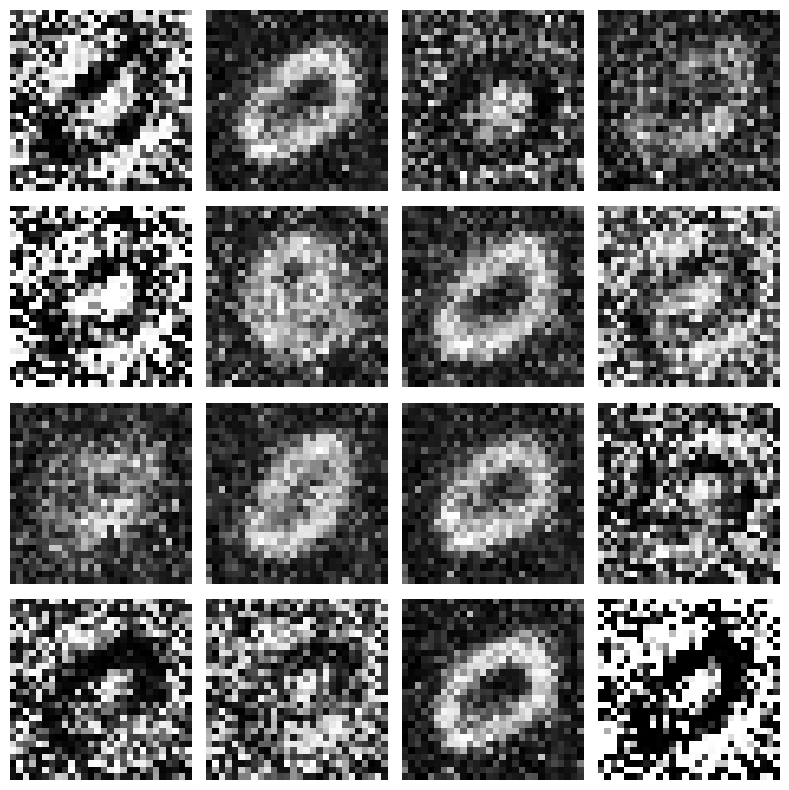

In [14]:
import matplotlib.pyplot as plt

# Visualize some generated images
fig, axs = plt.subplots(4, 4, figsize=(8, 8))
count = 0
for i in range(4):
    for j in range(4):
        axs[i, j].imshow(gen_imgs[count, :, :, 0], cmap='gray')  # Assuming grayscale images
        axs[i, j].axis('off')
        count += 1
plt.tight_layout()
plt.show()
